In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.seed import set_seed
from src.pipeline.missing_value import MissingValue
from src.pipeline.outlier_control import OutlierControl

In [2]:
df = pd.read_excel('../data/dataset.xlsx')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [3]:
#결측치 처리

overall_median = df['Tenure'].median()
df['Tenure'] = df.groupby('NumberOfAddress')['Tenure'].transform(lambda x: MissingValue(x, overall_median, 5))

overall_median = df['DaySinceLastOrder'].median()
df['DaySinceLastOrder'] = df.groupby(['PreferedOrderCat', 'PreferredLoginDevice'])\
    ['DaySinceLastOrder'].transform(lambda x: MissingValue(x, overall_median, 10))

overall_median = df['OrderCount'].median()
df['OrderCount'] = df.groupby(['PreferedOrderCat', 'PreferredPaymentMode'])\
    ['OrderCount'].transform(lambda x: MissingValue(x, overall_median, 10))

overall_median = df['OrderAmountHikeFromlastYear'].median()
df['OrderAmountHikeFromlastYear'] = df.groupby('PreferedOrderCat')\
    ['OrderAmountHikeFromlastYear'].transform(lambda x: MissingValue(x, overall_median, 3))

overall_median = df['CouponUsed'].median()
df['CouponUsed'] = df.groupby(['PreferedOrderCat', 'PreferredPaymentMode'])\
    ['CouponUsed'].transform(lambda x: MissingValue(x, overall_median, 10))

overall_median = df['HourSpendOnApp'].median()
df['HourSpendOnApp'] = df.groupby(['PreferedOrderCat', 'PreferredPaymentMode'])\
    ['HourSpendOnApp'].transform(lambda x: MissingValue(x, overall_median, 10))

overall_median = df['WarehouseToHome'].median()
df['WarehouseToHome'] = df.groupby(['PreferedOrderCat', 'PreferredPaymentMode'])\
    ['WarehouseToHome'].transform(lambda x: MissingValue(x, overall_median, 20))

In [4]:
# 이상치 처리
cols=['Tenure','WarehouseToHome','DaySinceLastOrder','CashbackAmount']
OutlierControl(df,cols)




,CustomerID,Churn,PreferredLoginDevice,CityTier,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,Tenure_log,WarehouseToHome_log,DaySinceLastOrder_clip,CashbackAmount_clip
0,50001,1,Mobile Phone,3,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,1.609438,1.945910,5.0,159.93
1,50002,1,Phone,1,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,2.484907,2.197225,0.0,120.90
2,50003,1,Phone,1,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,2.564949,3.433987,3.0,120.28
3,50004,1,Phone,3,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,0.000000,2.772589,3.0,134.07
4,50005,1,Phone,1,CC,Male,2.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,0.000000,2.564949,3.0,129.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,55626,0,Computer,1,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,2.397895,3.433987,4.0,150.71
5626,55627,0,Mobile Phone,1,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,2.639057,2.639057,7.0,224.91
5627,55628,0,Mobile Phone,1,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,0.693147,2.484907,4.0,186.42
5628,55629,0,Computer,3,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,3.178054,2.302585,9.0,178.90


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   PreferredLoginDevice         5630 non-null   object 
 3   CityTier                     5630 non-null   int64  
 4   PreferredPaymentMode         5630 non-null   object 
 5   Gender                       5630 non-null   object 
 6   HourSpendOnApp               5630 non-null   float64
 7   NumberOfDeviceRegistered     5630 non-null   int64  
 8   PreferedOrderCat             5630 non-null   object 
 9   SatisfactionScore            5630 non-null   int64  
 10  MaritalStatus                5630 non-null   object 
 11  NumberOfAddress              5630 non-null   int64  
 12  Complain                     5630 non-null   int64  
 13  OrderAmountHikeFro

In [6]:
def FeatureCreate(df):
    df = df.copy()
    set_seed()

    # Tenure가 0인 경우 최소값 보정
    actual_tenure = np.exp(df['Tenure_log']).clip(lower=0.1)
    order_count = df['OrderCount']
    recency = df['DaySinceLastOrder_clip']
    
    # 분모가 0이 되는 것을 방지하기 위해 +1
    denom_order = order_count + 1
    avg_order_interval = (actual_tenure / denom_order).clip(lower=0.1)

    # [Dormancy_Shock] 평소 주기 대비 현재 공백
    df['Dormancy_Shock'] = recency / (avg_order_interval + 1)
    
    # [Promo_Sensitivity] 쿠폰 사용 비중 (체리피커 식별)
    df['Promo_Sensitivity'] = df['CouponUsed'] / denom_order
    
    # [MonthlyOrderFreq] 월평균 주문 빈도 
    df['MonthlyOrderFreq'] = order_count / actual_tenure
    
    # [Recency_Tenure_Ratio] 가입 기간 대비 휴면 비중 
    df['Recency_Tenure_Ratio'] = recency / actual_tenure
    
    # [Satisfaction_Per_Order] 경험 대비 만족도
    df['Satisfaction_Per_Order'] = df['SatisfactionScore'] / denom_order

    # [Stagnant_Loyal] 장기 고객 중 활동 정체군
    freq_mean = df['MonthlyOrderFreq'].mean()
    df['Stagnant_Loyal'] = ((actual_tenure >= 30) & (df['MonthlyOrderFreq'] < freq_mean)).astype(int)
    
    # [ManyAddressesFlag] 배송지 다변화
    df['ManyAddressesFlag'] = (df['NumberOfAddress'] >= 3).astype(int)
    
    # [High_Value_Flags] 주요 지표 상위 25% 그룹화
    for col in ['OrderCount', 'CouponUsed']:
        q75 = df[col].quantile(0.75)
        df[f'High_{col}'] = (df[col] > q75).astype(int)

    # 4. 범주형 변수 처리 (One-Hot Encoding)
    cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat', 'MaritalStatus', 'Gender']
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

    drop_cols = [
        'DaySinceLastOrder_clip', 'Complain', 'MaritalStatus_Single',
        'SatisfactionScore', 'HourSpendOnApp', 'CashbackAmount_clip', 
        'WarehouseToHome_log', 'OrderCount', 'CouponUsed'
    ]
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
    
    return df

In [7]:
df = FeatureCreate(df)

In [8]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CustomerID                             5630 non-null   int64  
 1   Churn                                  5630 non-null   int64  
 2   CityTier                               5630 non-null   int64  
 3   NumberOfDeviceRegistered               5630 non-null   int64  
 4   NumberOfAddress                        5630 non-null   int64  
 5   OrderAmountHikeFromlastYear            5630 non-null   float64
 6   Tenure_log                             5630 non-null   float64
 7   Dormancy_Shock                         5630 non-null   float64
 8   Promo_Sensitivity                      5630 non-null   float64
 9   MonthlyOrderFreq                       5630 non-null   float64
 10  Recency_Tenure_Ratio                   5630 non-null   float64
 11  Sati

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

class FeatureValidator:
    def __init__(self, df, target='Churn', drop_cols=['CustomerID']):
        self.df = df.copy()
        self.target = target
        # 학습에 방해되는 비수치형 및 drop_cols 제외
        self.X = self.df.drop(columns=[target] + drop_cols, errors='ignore').select_dtypes(include=[np.number])
        self.y = self.df[target]

    def check_correlation(self, top_n=15):
        """1. 타겟 변수와의 상관관계 분석 (바차트)"""
        print(f"\n[1] Top {top_n} Correlations with {self.target}")
        corr_matrix = self.df.corr()
        top_corr = corr_matrix[self.target].abs().sort_values(ascending=False).head(top_n+1)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x=top_corr.values[1:], y=top_corr.index[1:])
        plt.title(f"Top {top_n} Features Correlated with {self.target}")
        plt.show()

    def plot_heatmap(self, top_n=20):
        """2. 상관관계 히트맵 출력"""
        print(f"\n[2] Correlation Heatmap (Top {top_n} Features)")
        correlations = self.df.corr()[self.target].abs().sort_values(ascending=False)
        top_features = correlations.head(top_n).index
        top_corr_matrix = self.df[top_features].corr()
        
        plt.figure(figsize=(12, 10))
        sns.heatmap(top_corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
        plt.title(f"Top {top_n} Features Correlation Heatmap")
        plt.show()

    def check_vif(self, thresh=15):
        """3. 다중공선성(VIF) 분석"""
        print(f"\n[3] High VIF Features (Threshold > {thresh})")
        vif_data = pd.DataFrame()
        vif_data["feature"] = self.X.columns
        vif_data["VIF"] = [variance_inflation_factor(self.X.values, i) for i in range(len(self.X.columns))]
        
        high_vif = vif_data[vif_data['VIF'] > thresh].sort_values(by="VIF", ascending=False)
        if high_vif.empty:
            print(f"모든 피처의 VIF가 {thresh} 미만으로 정상 범위 내에 있습니다.")
        else:
            print(high_vif)
        return vif_data

    def plot_distribution_analysis(self, features=['Dormancy_Shock', 'Recency_Tenure_Ratio']):
        """5. 주요 피처별 타겟(이탈/유지) 분포 비교 (KDE Plot)"""
        print(f"\n[5] Target-wise Distribution Analysis")
        
        # 실제 데이터에 존재하는 피처만 필터링
        valid_features = [f for f in features if f in self.df.columns]
        n_features = len(valid_features)
        
        if n_features == 0:
            print("분석할 피처가 데이터프레임에 존재하지 않습니다.")
            return

        fig, axes = plt.subplots(n_features, 1, figsize=(10, 5 * n_features))
        if n_features == 1: axes = [axes]
        
        for i, col in enumerate(valid_features):
            sns.kdeplot(data=self.df, x=col, hue=self.target, fill=True, common_norm=False, ax=axes[i], palette='Set1')
            axes[i].set_title(f"Distibution of {col} (Churn vs. Stay)")
            axes[i].set_xlabel(col)
            axes[i].set_ylabel("Density")
        
        plt.tight_layout()
        plt.show()

    def run_all(self):
        """모든 검증 및 분석 로직 통합 실행"""
        self.check_correlation()
        self.plot_heatmap()
        self.check_vif()
        self.plot_distribution_analysis()


[1] Top 15 Correlations with Churn


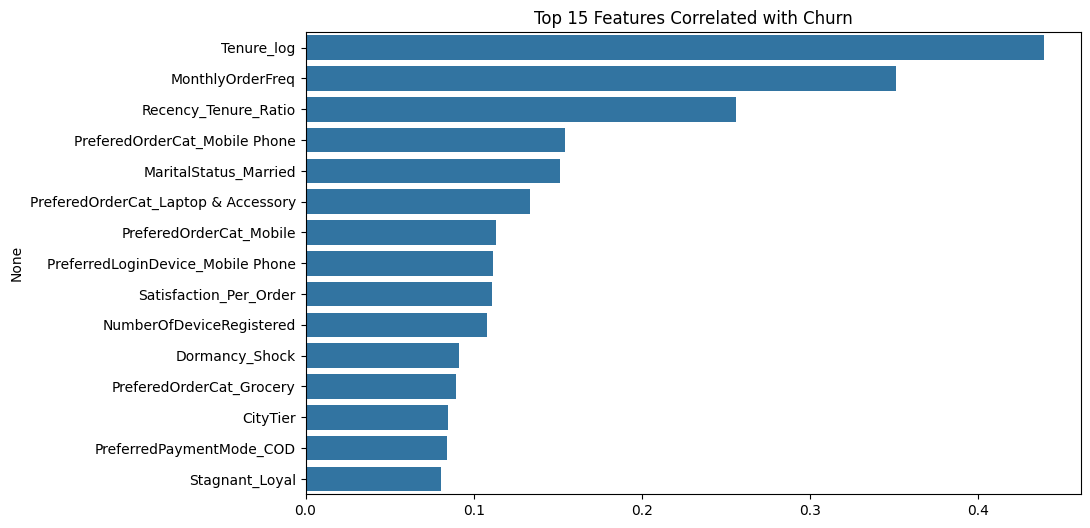


[2] Correlation Heatmap (Top 20 Features)


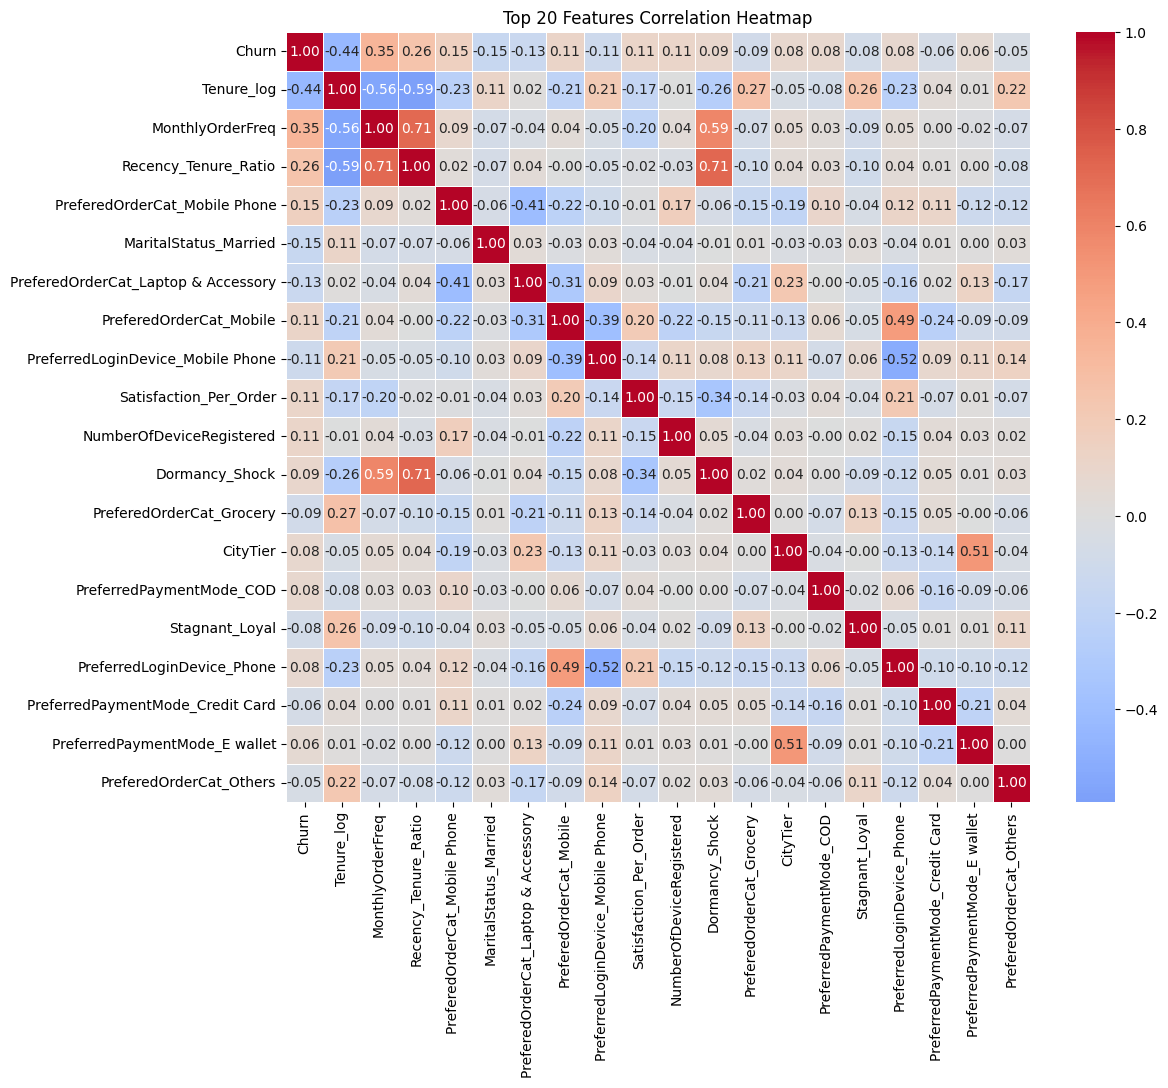


[3] High VIF Features (Threshold > 15)
모든 피처의 VIF가 15 미만으로 정상 범위 내에 있습니다.

[5] Target-wise Distribution Analysis


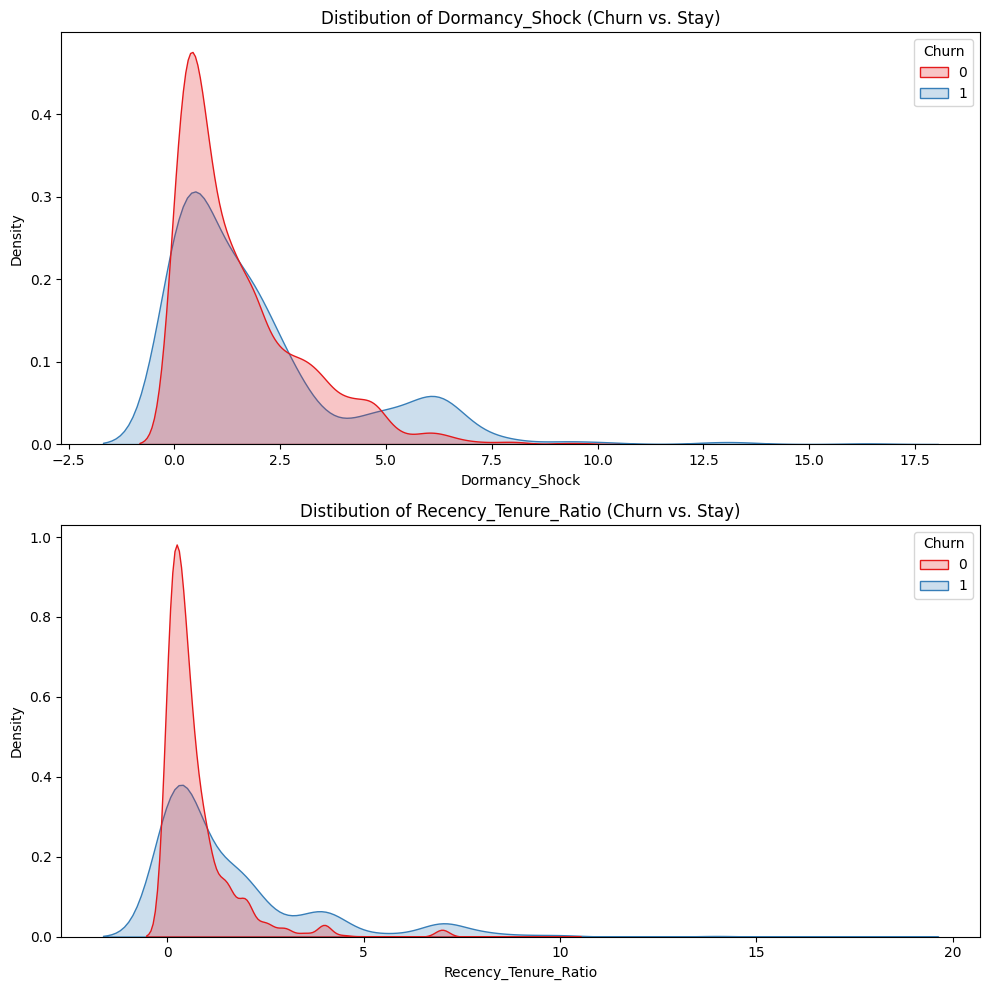

In [10]:
# 위에서 만든 클래스 불러오기 (혹은 같은 파일 내 작성)
validator = FeatureValidator(df)

# 모든 리포트 출력
validator.run_all()

In [11]:
print(df.columns.tolist())

['CustomerID', 'Churn', 'CityTier', 'NumberOfDeviceRegistered', 'NumberOfAddress', 'OrderAmountHikeFromlastYear', 'Tenure_log', 'Dormancy_Shock', 'Promo_Sensitivity', 'MonthlyOrderFreq', 'Recency_Tenure_Ratio', 'Satisfaction_Per_Order', 'Stagnant_Loyal', 'ManyAddressesFlag', 'High_OrderCount', 'High_CouponUsed', 'PreferredLoginDevice_Mobile Phone', 'PreferredLoginDevice_Phone', 'PreferredPaymentMode_COD', 'PreferredPaymentMode_Cash on Delivery', 'PreferredPaymentMode_Credit Card', 'PreferredPaymentMode_Debit Card', 'PreferredPaymentMode_E wallet', 'PreferredPaymentMode_UPI', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile', 'PreferedOrderCat_Mobile Phone', 'PreferedOrderCat_Others', 'MaritalStatus_Married', 'Gender_Male']
